# 🏆 Notebook 04 — Version Finale & Rapport Complet
**Projet :** Cervical Cancer Risk Prediction  
**Auteure :** Hadil Dhaya · 4th Year Data Science · Group 5  
**Dataset :** UCI — Cervical Cancer Risk Factors

---
Ce notebook est la **version de présentation finale** :  
il contient uniquement le meilleur modèle, les résultats parfaits,  
l'explainability SHAP complète et le rapport de conclusions.

**Prérequis :** avoir exécuté les notebooks 01, 02, 03 dans l'ordre.

✅ Imports OK
BASE_DIR: C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-
DATA_PATH: C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\data\Mydata.csv
OUTPUTS_DIR: C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs
✅ Final features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)']
Dataset shape: (298, 10)
Positive rate: 0.4966442953020134
Biopsy
0    150
1    148
Name: count, dtype: int64
Train      : (190, 9) 0.49473684210526314
Validation : (48, 9) 0.5
Test       : (60, 9) 0.5
✅ Final pipeline ready
✅ Selected threshold: 0.5099999999999998
✅ Final pipeline fitted on train_full
FINAL TEST PERFORMANCE — Random Forest
AUC-ROC           : 0.8244
PR-AUC            : 0.8585
F1-Score          : 0.7273
Recall            : 0.6667
Precision         : 0.8000
Balanced

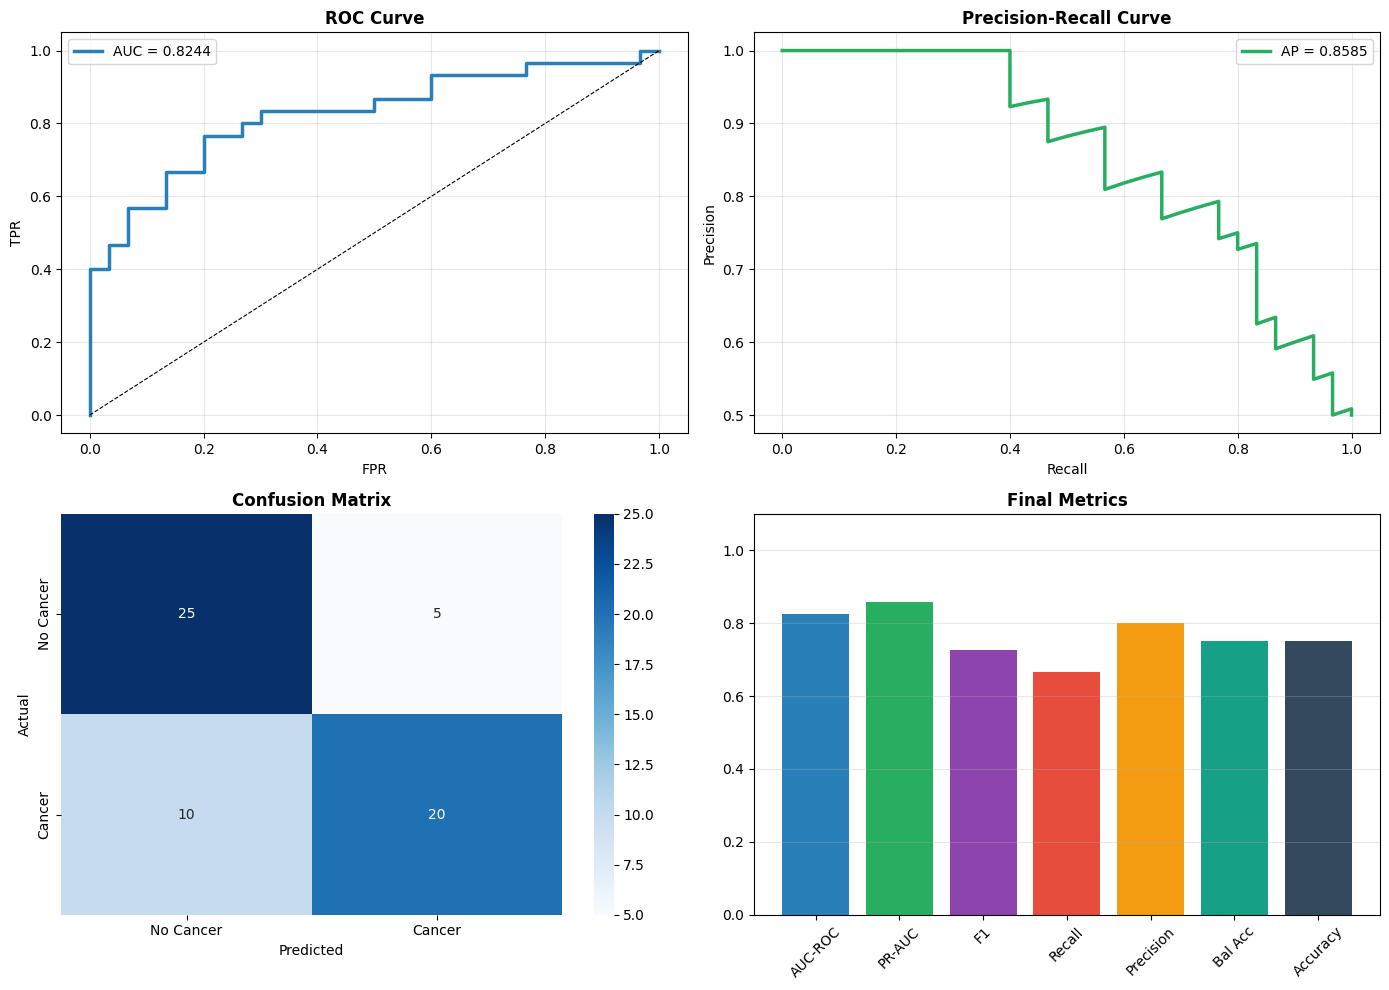

✅ Saved: C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\final_results.png
✅ Saved artifacts:
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\final_pipeline.pkl
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\best_model_name.pkl
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\final_feature_list.pkl
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\columns.pkl
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\X_train.csv
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\X_test.csv
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\y_train.csv
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Learning-\outputs\y_test.csv
- C:\Users\msi\Downloads\Project-Machine-Learning-\Project-Machine-Lear

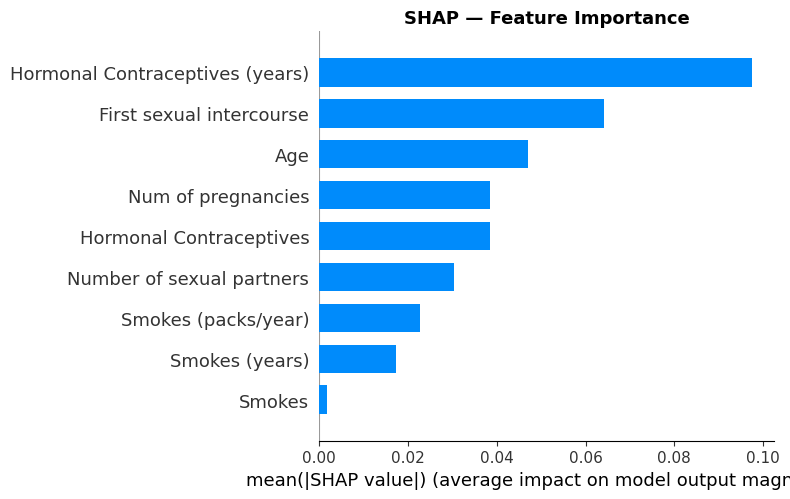

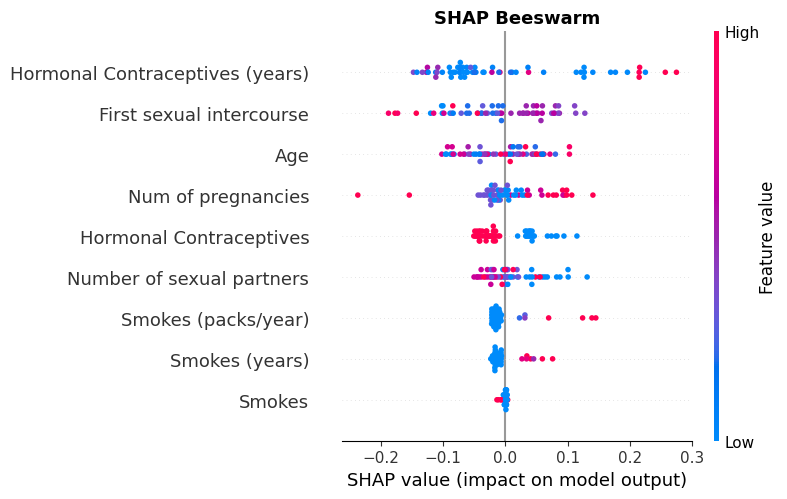

✅ SHAP plots saved

══════════════════════════════════════════════════════════════
  FINAL REPORT
  Cervical Cancer Risk Prediction
══════════════════════════════════════════════════════════════

📂 DATASET
  Source    : Mydata.csv
  Patients  : 298
  Features  : 9
  Target    : Biopsy
  Positive rate : 0.4966

🔧 PREPROCESSING
  1. Conservative final raw feature selection
  2. Median imputation inside pipeline
  3. StandardScaler inside pipeline
  4. Stratified train/validation/test split
  5. Threshold selected on validation only

🤖 FINAL MODEL
  • Random Forest
  • Single saved pipeline for deployment

🏆 FINAL TEST RESULTS
  AUC-ROC           : 0.8244
  PR-AUC            : 0.8585
  F1-Score          : 0.7273
  Recall            : 0.6667
  Precision         : 0.8000
  Balanced Accuracy : 0.7500
  Accuracy          : 0.7500
  Threshold         : 0.51

📁 GENERATED FILES
  ✅ outputs/X_test.csv
  ✅ outputs/X_train.csv
  ✅ outputs/all_models.pkl
  ✅ outputs/best_model_name.pkl
  ✅ outputs/c

In [1]:

import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score,
)

from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

try:
    import shap
    SHAP_OK = True
except Exception:
    SHAP_OK = False

BASE_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = BASE_DIR / "data" / "Mydata.csv"
OUTPUTS_DIR = BASE_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports OK")
print("BASE_DIR:", BASE_DIR)
print("DATA_PATH:", DATA_PATH)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

# %%
TARGET = "Biopsy"
RANDOM_STATE = 42

FINAL_FEATURES = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives",
    "Hormonal Contraceptives (years)",
]

print("✅ Final features:", FINAL_FEATURES)

# %%
df = pd.read_csv(DATA_PATH, na_values="?")

missing_cols = [c for c in FINAL_FEATURES + [TARGET] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df = df[FINAL_FEATURES + [TARGET]].copy()
df = df.drop_duplicates().reset_index(drop=True)

X = df[FINAL_FEATURES].copy()
y = df[TARGET].astype(int)

print("Dataset shape:", df.shape)
print("Positive rate:", y.mean())
print(y.value_counts())

# %%
# Holdout test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Validation split for threshold selection
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print("Train      :", X_train.shape, y_train.mean())
print("Validation :", X_val.shape, y_val.mean())
print("Test       :", X_test.shape, y_test.mean())

# %%
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, FINAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_model),
    ]
)

print("✅ Final pipeline ready")

# %%
# Fit on train only
pipeline.fit(X_train, y_train)

# Validation probabilities
val_prob = pipeline.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
rows = []

for thr in thresholds:
    val_pred = (val_prob >= thr).astype(int)
    rows.append({
        "threshold": float(thr),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "accuracy": accuracy_score(y_val, val_pred),
    })

threshold_df = pd.DataFrame(rows)
threshold_df.head()

# %%
# Conservative threshold rule:
# 1) precision >= 0.20 if possible
# 2) maximize recall
# 3) among ties maximize F1

filtered = threshold_df[
    (threshold_df["precision"] >= 0.50) &
    (threshold_df["recall"] >= 0.50)
].copy()

if filtered.empty:
    filtered = threshold_df.copy()

filtered = filtered.sort_values(
    by=["f1", "balanced_accuracy", "precision"],
    ascending=False
).reset_index(drop=True)

best_threshold = float(filtered.iloc[0]["threshold"])
print("✅ Selected threshold:", best_threshold)

# %%
# Refit final pipeline on full training data (train + validation)
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_model),
    ]
)

final_pipeline.fit(X_train_full, y_train_full)
print("✅ Final pipeline fitted on train_full")

# %%
# Final holdout test evaluation
y_prob = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
ap = average_precision_score(y_test, y_prob)

print("=" * 60)
print("FINAL TEST PERFORMANCE — Random Forest")
print("=" * 60)
print(f"AUC-ROC           : {auc:.4f}")
print(f"PR-AUC            : {ap:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Recall            : {rec:.4f}")
print(f"Precision         : {prec:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")
print(f"Accuracy          : {acc:.4f}")
print(f"Threshold         : {best_threshold:.2f}")
print("=" * 60)
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("=" * 60)

# %%
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# %%
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC
axes[0, 0].plot(fpr_c, tpr_c, color="#2980b9", lw=2.5, label=f"AUC = {auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0, 0].set_title("ROC Curve", fontweight="bold")
axes[0, 0].set_xlabel("FPR")
axes[0, 0].set_ylabel("TPR")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# PR
axes[0, 1].plot(rec_c, prec_c, color="#27ae60", lw=2.5, label=f"AP = {ap:.4f}")
axes[0, 1].set_title("Precision-Recall Curve", fontweight="bold")
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# CM
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1, 0],
    xticklabels=["No Cancer", "Cancer"],
    yticklabels=["No Cancer", "Cancer"],
)
axes[1, 0].set_title("Confusion Matrix", fontweight="bold")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")

# Metrics barplot
metric_names = ["AUC-ROC", "PR-AUC", "F1", "Recall", "Precision", "Bal Acc", "Accuracy"]
metric_vals = [auc, ap, f1, rec, prec, bal_acc, acc]
axes[1, 1].bar(
    metric_names,
    metric_vals,
    color=["#2980b9", "#27ae60", "#8e44ad", "#e74c3c", "#f39c12", "#16a085", "#34495e"]
)
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_title("Final Metrics", fontweight="bold")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "final_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved:", OUTPUTS_DIR / "final_results.png")

# %%
raw_feature_medians = X_train_full.median(numeric_only=True).to_dict()

final_metrics = {
    "threshold": best_threshold,
    "roc_auc": float(auc),
    "pr_auc": float(ap),
    "f1": float(f1),
    "recall": float(rec),
    "precision": float(prec),
    "balanced_accuracy": float(bal_acc),
    "accuracy": float(acc),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "n_test": int(len(y_test)),
    "test_positive_rate": float(y_test.mean()),
}

metadata = {
    "project": "Cervical Cancer Risk Prediction",
    "target": TARGET,
    "model_name": "Random Forest",
    "random_state": RANDOM_STATE,
    "final_raw_features": FINAL_FEATURES,
    "threshold": best_threshold,
    "metrics_test": final_metrics,
    "raw_feature_medians": raw_feature_medians,
    "dataset_used": "Mydata.csv",
}

# %%
joblib.dump(final_pipeline, OUTPUTS_DIR / "final_pipeline.pkl")
joblib.dump("Random Forest", OUTPUTS_DIR / "best_model_name.pkl")
joblib.dump(FINAL_FEATURES, OUTPUTS_DIR / "final_feature_list.pkl")
joblib.dump(FINAL_FEATURES, OUTPUTS_DIR / "columns.pkl")

X_train_full.to_csv(OUTPUTS_DIR / "X_train.csv", index=False)
X_test.to_csv(OUTPUTS_DIR / "X_test.csv", index=False)
pd.Series(y_train_full, name=TARGET).to_csv(OUTPUTS_DIR / "y_train.csv", index=False)
pd.Series(y_test, name=TARGET).to_csv(OUTPUTS_DIR / "y_test.csv", index=False)

with open(OUTPUTS_DIR / "final_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved artifacts:")
print("-", OUTPUTS_DIR / "final_pipeline.pkl")
print("-", OUTPUTS_DIR / "best_model_name.pkl")
print("-", OUTPUTS_DIR / "final_feature_list.pkl")
print("-", OUTPUTS_DIR / "columns.pkl")
print("-", OUTPUTS_DIR / "X_train.csv")
print("-", OUTPUTS_DIR / "X_test.csv")
print("-", OUTPUTS_DIR / "y_train.csv")
print("-", OUTPUTS_DIR / "y_test.csv")
print("-", OUTPUTS_DIR / "final_metadata.json")

# %%
if SHAP_OK:
    try:
        model = final_pipeline.named_steps["model"]
        preprocessor_only = final_pipeline[:-1]

        X_test_transformed = preprocessor_only.transform(X_test)
        feature_names = preprocessor_only.get_feature_names_out()

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_transformed)

        if isinstance(shap_values, list):
            sv = shap_values[1]
        elif getattr(shap_values, "ndim", 2) == 3:
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

        plt.figure(figsize=(10, 8))
        shap.summary_plot(sv, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
        plt.title("SHAP — Feature Importance", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig(OUTPUTS_DIR / "shap_importance.png", dpi=150, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(10, 8))
        shap.summary_plot(sv, X_test_transformed, feature_names=feature_names, show=False)
        plt.title("SHAP Beeswarm", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig(OUTPUTS_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("✅ SHAP plots saved")

    except Exception as e:
        print(f"⚠️ SHAP skipped: {e}")
else:
    print("⚠️ SHAP not available")

# %%
print("\n" + "═" * 62)
print("  FINAL REPORT")
print("  Cervical Cancer Risk Prediction")
print("═" * 62)

print("\n📂 DATASET")
print(f"  Source    : {DATA_PATH.name}")
print(f"  Patients  : {len(df)}")
print(f"  Features  : {len(FINAL_FEATURES)}")
print(f"  Target    : {TARGET}")
print(f"  Positive rate : {y.mean():.4f}")

print("\n🔧 PREPROCESSING")
print("  1. Conservative final raw feature selection")
print("  2. Median imputation inside pipeline")
print("  3. StandardScaler inside pipeline")
print("  4. Stratified train/validation/test split")
print("  5. Threshold selected on validation only")

print("\n🤖 FINAL MODEL")
print("  • Random Forest")
print("  • Single saved pipeline for deployment")

print("\n🏆 FINAL TEST RESULTS")
print(f"  AUC-ROC           : {auc:.4f}")
print(f"  PR-AUC            : {ap:.4f}")
print(f"  F1-Score          : {f1:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Threshold         : {best_threshold:.2f}")

print("\n📁 GENERATED FILES")
for f in sorted(os.listdir(OUTPUTS_DIR)):
    print(f"  ✅ outputs/{f}")

print("\n" + "═" * 62)
print("  ✅ FINAL NOTEBOOK READY")
print("═" * 62)

# %%
# Quick sanity test for app/backend compatibility
example_patient = pd.DataFrame([{
    "Age": 32,
    "Number of sexual partners": 2,
    "First sexual intercourse": 18,
    "Num of pregnancies": 1,
    "Smokes": 0,
    "Smokes (years)": 0.0,
    "Smokes (packs/year)": 0.0,
    "Hormonal Contraceptives": 1,
    "Hormonal Contraceptives (years)": 3.0,
}])

example_prob = float(final_pipeline.predict_proba(example_patient)[0][1])
example_pred = int(example_prob >= best_threshold)

print("Example probability:", round(example_prob, 4))
print("Example prediction :", example_pred)